In [1]:
# %pip install --upgrade pandas numpy scipy scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

pd.set_option('display.max_columns', None)

# for reproducibility
RANDOM = 44

### Feature Engineering and Data Cleaning

Based on results from EDA

The following steps will be taken to prep data for machine learning:

*Remove cols:*
- price - keeping price_usd as price variable
- ships_worldwide - highly correlated with seller_listing_count

Likely will not use any graded cols in the final result but will keep in case I do.

*Features created:*
- price_usd_log.- logarithm of price_usd for more normal dist
- title_length - character count of title of card
- 



### Notes:

For this analysis I have decided to drop grading related columns, as these are generally a different product than raw cards are. These are more collectible items and have different utility when graded. Since only a small fraction of the entries in this dataset are graded, I will be dropping them to their own dataset, but could add them back in if necessary.

In [2]:
df = pd.read_csv('./pokemon_cards_ultimate_2026.csv')

# keep as separate df just in case
df_graded = df[df['is_graded'] == 1]

# keep original dataframe with ungraded cards
df = df[df['is_graded'] != 1]  

# drop graded related cols from the ungraded dataset
grading_cols = ['is_graded', 'grading_company', 'numeric_grade']
df = df.drop(columns=grading_cols)

# **NOTES** All of these records in the dataset were captured in a very small timeframe, therefore the columns relating to sale month, year, etc will be dropped.
selling_cols = ['days_since_sold', 'sale_month', 'sale_year']
df = df.drop(columns=selling_cols)

df.info()

<class 'pandas.DataFrame'>
Index: 503 entries, 0 to 541
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 503 non-null    str    
 1   pokemon_name          503 non-null    str    
 2   set_name              503 non-null    str    
 3   card_number           395 non-null    str    
 4   rarity_class          503 non-null    str    
 5   language              503 non-null    str    
 6   category              503 non-null    str    
 7   condition_std         503 non-null    str    
 8   is_holo               503 non-null    int64  
 9   is_full_art           503 non-null    int64  
 10  is_v_card             503 non-null    int64  
 11  is_ex_card            503 non-null    int64  
 12  is_gx_card            503 non-null    int64  
 13  is_promo              503 non-null    int64  
 14  is_shadowless         503 non-null    int64  
 15  is_1st_edition        503 non-null    i

In [3]:
# check out missing and duplicate entries
missing = df.isna().sum()
missing = missing.sort_values(ascending=False)
print(missing)

dups = df.duplicated()
display(df[dups])

card_number             108
title                     0
is_shadowless             0
ships_worldwide           0
seller_listing_count      0
seller_country            0
price_tier_usd            0
price_usd                 0
currency                  0
price                     0
is_gold                   0
is_rainbow                0
is_1st_edition            0
is_promo                  0
pokemon_name              0
is_gx_card                0
is_ex_card                0
is_v_card                 0
is_full_art               0
is_holo                   0
condition_std             0
category                  0
language                  0
rarity_class              0
set_name                  0
image_count               0
dtype: int64


,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count
29,Emboar Holo 008/037 HS 2010 Vintage Rare Ninte...,Unknown,Unknown,008/037,Rare,Japanese,Single Cards,Excellent,1,0,0,0,0,0,0,0,0,0,1.0,EUR,1.17,Budget,Germany,114,1,2


In [4]:
# drop single duplicated row -> overwhlemingly likely to be an erroneous record
df = df.drop_duplicates()

For card number, I am going to separate into 2 cols, the card number (first number before the slash), and the second number is the number of cards in the set. I will potentially also create a new column that is the position in the set by a percentage?

In [5]:
# split between the /
df[['card_number', 'set_card_amount']] = df['card_number'].astype(str).str.split('/', n=1, expand=True)

# convert to ints
df['card_number'] = pd.to_numeric(df['card_number'], errors='coerce').astype('Int64') 
df['set_card_amount'] = pd.to_numeric(df['set_card_amount'], errors='coerce').astype('Int64') 

In [6]:
df[['card_number', 'set_card_amount']].describe()

,card_number,set_card_amount
count,394.0,394.0
mean,81.091371,115.568528
std,72.45788,51.111131
min,1.0,12.0
25%,23.0,80.0
50%,67.0,102.0
75%,108.0,146.25
max,401.0,236.0


For this analysis I am going to impute the mean to all missing cols in the card number and set card amount to the missing values. Since there are outliers, this should account for outliers too.

In [7]:
print(df['card_number'].median())
print(df['set_card_amount'].median())

67.0
102.0


In [8]:
df['card_number'] = df['card_number'].fillna(df['card_number'].median())
df['set_card_amount'] = df['set_card_amount'].fillna(df['set_card_amount'].median())

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 502 entries, 0 to 541
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 502 non-null    str    
 1   pokemon_name          502 non-null    str    
 2   set_name              502 non-null    str    
 3   card_number           502 non-null    Int64  
 4   rarity_class          502 non-null    str    
 5   language              502 non-null    str    
 6   category              502 non-null    str    
 7   condition_std         502 non-null    str    
 8   is_holo               502 non-null    int64  
 9   is_full_art           502 non-null    int64  
 10  is_v_card             502 non-null    int64  
 11  is_ex_card            502 non-null    int64  
 12  is_gx_card            502 non-null    int64  
 13  is_promo              502 non-null    int64  
 14  is_shadowless         502 non-null    int64  
 15  is_1st_edition        502 non-null    i

In [10]:
# copy over for encoding variables
df_cleaned = df.copy()

# title will not be used in the model as it is a string variable, create a title length variable as a surrogate
df_cleaned['title_length'] = df_cleaned['title'].str.len()
df_cleaned = df_cleaned.drop(columns='title')

# pokemon name and set name are both going to be nominal categorical variables
# using pandas get_dummies to encode for machine learning methods
nominal_categorical = ["pokemon_name", 'set_name', 'language']
# make these all lowercase only first
# for col in nominal_categorical:
#     df_cleaned[col] = df_cleaned[col].str.lower()
# df_cleaned = pd.get_dummies(df_cleaned, columns=nominal_categorical, dtype=int)

# ordinal categorical values:
# rarity class - this has order -> these are in order according to pokemon card sources
ordered_rarities = [
    "Unknown",
    "Common",
    "Uncommon",
    "Rare",
    "Rare Holo",
    "RR",
    "AR",
    "IR",
    "SR",
    "UR",
    "SAR",
    "SIR",
    "HR",
]
df_cleaned["rarity_class"] = pd.Categorical(
    df_cleaned["rarity_class"], categories=ordered_rarities, ordered=True
)
df_cleaned["rarity_class"] = df_cleaned["rarity_class"].cat.codes

# condition states according to research done on the topic
ordered_conditons = [
    "Very Good",
    "Lightly Played",
    "Excellent",
    "Near Mint",
]
df_cleaned['condition_std'] = pd.Categorical(
    df_cleaned['condition_std'], categories=ordered_conditons, ordered=True
)
df_cleaned['condition_std'] = df_cleaned['condition_std'].cat.codes

In [11]:
# the following cols should not impact the inherent value of the card, but rather could have other costs associated such as shipping costs, etc so will be removed for modeling
# seller_country, seller_listing_count, ships_worldwide, image_count
# uninformative cols to drop
# cateogory - same meaning for all
# currency - using usd as standard
# price_tier_usd - likely highly correlated with response variable
cols_to_drop = [
    'seller_country',
    'seller_listing_count',
    'ships_worldwide',
    'image_count',
    'category',
    'currency',
    'price_tier_usd'
]

df_cleaned = df_cleaned.drop(columns=cols_to_drop)
df_cleaned.head()

,pokemon_name,set_name,card_number,rarity_class,language,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,price_usd,set_card_amount,title_length
0,Ceruledge,SV8A,203,10,Japanese,3,0,0,0,1,0,0,0,0,0,0,15.43,20.99,187,70
1,Zacian,S12A,225,10,Japanese,3,1,0,1,0,0,0,0,0,0,0,11.15,15.17,172,67
2,Piplup,INFERNO X,85,6,Japanese,3,0,0,0,0,0,0,0,0,0,0,2.91,3.96,80,70
3,Kyurem,XY,25,0,English,3,1,0,0,1,0,0,0,0,0,0,2.29,3.12,98,71
4,Vulpix,MEGA BRAVE,67,6,Japanese,3,0,0,0,0,0,0,0,0,0,0,1.99,2.71,63,57


Maybe drop title length??????? as this is not an inherent property to the card itself???

In [12]:
# feature engineering
# log price
df_ml = df_cleaned.copy()

df_ml['price_log_usd'] = np.log10(df_ml['price_usd'] + 1)
df_ml = df_ml.drop(columns=['price', 'price_usd'])

# create a ratio col for card num / set card number
df_ml['set_position_ratio'] = df_ml['card_number'] / df_ml['set_card_amount']
df_ml = df_ml.drop(columns=['card_number', 'set_card_amount'])
 
df_ml

,pokemon_name,set_name,rarity_class,language,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,title_length,price_log_usd,set_position_ratio
0,Ceruledge,SV8A,10,Japanese,3,0,0,0,1,0,0,0,0,0,0,70,1.342225,1.085561
1,Zacian,S12A,10,Japanese,3,1,0,1,0,0,0,0,0,0,0,67,1.208710,1.30814
2,Piplup,INFERNO X,6,Japanese,3,0,0,0,0,0,0,0,0,0,0,70,0.695482,1.0625
3,Kyurem,XY,0,English,3,1,0,0,1,0,0,0,0,0,0,71,0.614897,0.255102
4,Vulpix,MEGA BRAVE,6,Japanese,3,0,0,0,0,0,0,0,0,0,0,57,0.569374,1.063492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,Charizard,Unknown,11,English,3,0,0,0,1,0,0,0,0,0,0,63,2.596982,1.206061
538,Lucario,Unknown,0,English,3,1,1,0,1,0,1,0,0,0,0,75,1.570076,0.656863
539,Blastoise,XY,3,English,3,1,1,0,1,0,0,0,0,0,0,80,1.104828,0.656863
540,Venusaur,Unknown,3,English,3,0,1,0,1,0,0,0,0,0,0,65,2.185032,1.340909


Dataset is now prepped for machine learning methods

**Notes:**

For determining the encoding of the condition_std col I used this source: https://pokescope.app/condition-guide/ to determine the row. 

Using this function from the scikitlearn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

Am condsidering separating graded cards from the rest of the dataset tbh, as the market for these is generally completely different...


---

## Model 1: Linear Regression Model

TODO: Need to ensure that the data is fully ready to be used on this, separate columns that will and will not be used for stuff, like date cols can be dropped. Additioanlly, keep the is_graded flag away from the other ones as it is quite niche and will obviously positively correlate to a high extent.

In [13]:
encoder = TargetEncoder(smooth="auto", cv=5)
df_ml['pokemon_encoded'] = encoder.fit_transform(df_ml[['pokemon_name']], df_ml['price_log_usd'])

df_ml['set_encoded'] = encoder.fit_transform(df_ml[['set_name']], df_ml['price_log_usd'])
df_ml['language_encoded'] = encoder.fit_transform(df_ml[['language']], df_ml['price_log_usd'])

categorical_cols = ['pokemon_name', 'set_name', 'language']
df_ml_reg = df_ml.drop(columns=categorical_cols)

df_ml_reg.head()

,rarity_class,condition_std,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,title_length,price_log_usd,set_position_ratio,pokemon_encoded,set_encoded,language_encoded
0,10,3,0,0,0,1,0,0,0,0,0,0,70,1.342225,1.085561,0.774517,0.871639,0.672128
1,10,3,1,0,1,0,0,0,0,0,0,0,67,1.208710,1.30814,0.868207,0.871127,0.696135
2,6,3,0,0,0,0,0,0,0,0,0,0,70,0.695482,1.0625,1.052120,0.624935,0.672128
3,0,3,1,0,0,1,0,0,0,0,0,0,71,0.614897,0.255102,0.866679,0.881899,0.983666
4,6,3,0,0,0,0,0,0,0,0,0,0,57,0.569374,1.063492,0.828928,0.842596,0.685318


In [14]:
X = df_ml_reg.drop(columns='price_log_usd')
y = df_ml_reg['price_log_usd']

In [15]:
# test train split 80/20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM
)

scaler = StandardScaler()
# scale data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 401
Test set size: 101


In [16]:
pokemon_lm = LinearRegression()
pokemon_lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[0.02,0.06,0.1 ,...,0.66,0.34,0.65]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['rarity_class','condition_std','is_holo',...,'pokemon_encoded', 'set_encoded','language_encoded']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.7485
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [17]:
y_pred = pokemon_lm.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f'Test RMSE: {test_rmse:.2f}')
print(f'Test R²:   {test_r2:.4f}')

Test RMSE: 0.49
Test R²:   0.1993


In [18]:
coef_df = pd.DataFrame({
    'Feature': X.columns if hasattr(X, 'columns') else range(X.shape[1]),
    'Coefficient': pokemon_lm.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

           Feature   Coefficient
   pokemon_encoded  6.555673e-01
  language_encoded  6.461003e-01
       set_encoded  3.441070e-01
       is_full_art  2.593234e-01
        is_gx_card -1.292379e-01
           is_holo  9.766382e-02
          is_promo  8.044562e-02
     condition_std  5.988292e-02
         is_v_card -4.361401e-02
      rarity_class  2.270775e-02
        is_ex_card  1.826510e-02
set_position_ratio  3.617111e-03
    is_1st_edition  2.374153e-03
      title_length -8.787562e-04
        is_rainbow -8.326673e-17
           is_gold  2.428613e-17
     is_shadowless  0.000000e+00


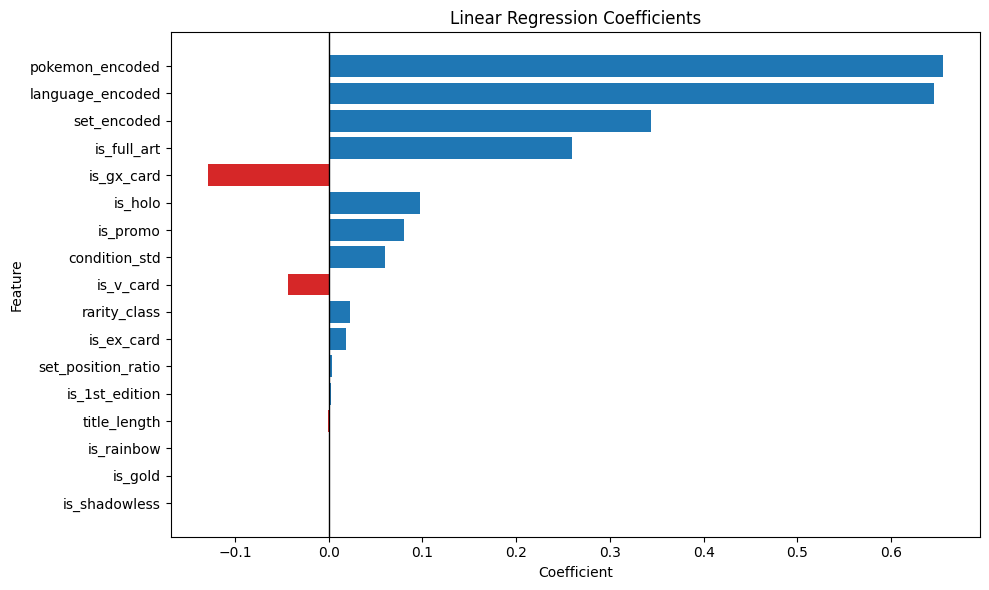

In [48]:
coef_plot_df = coef_df.copy()
coef_plot_df['abs_coef'] = coef_plot_df['Coefficient'].abs()
coef_plot_df = coef_plot_df.sort_values(by='abs_coef', ascending=False).head(20)

plt.figure(figsize=(10, 6))
colors = ['tab:blue' if c >= 0 else 'tab:red' for c in coef_plot_df['Coefficient']]
plt.barh(coef_plot_df['Feature'], coef_plot_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients')
plt.tight_layout()
plt.show()

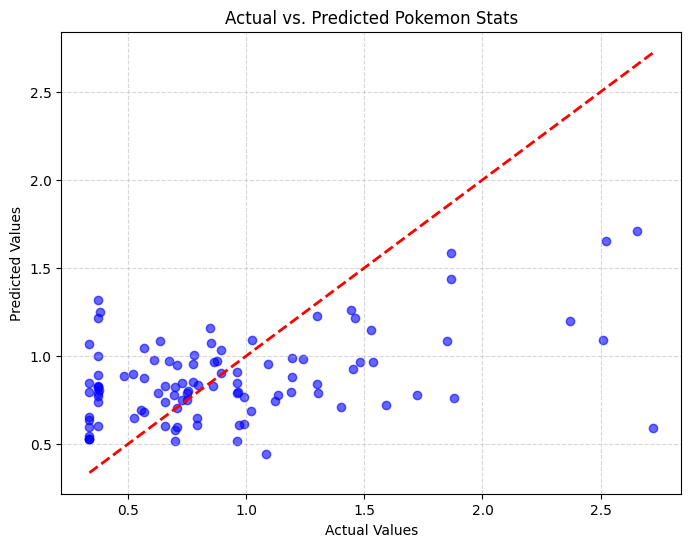

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')

# Red dashed diagonal line representing a perfect 1:1 prediction
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Pokemon Stats')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

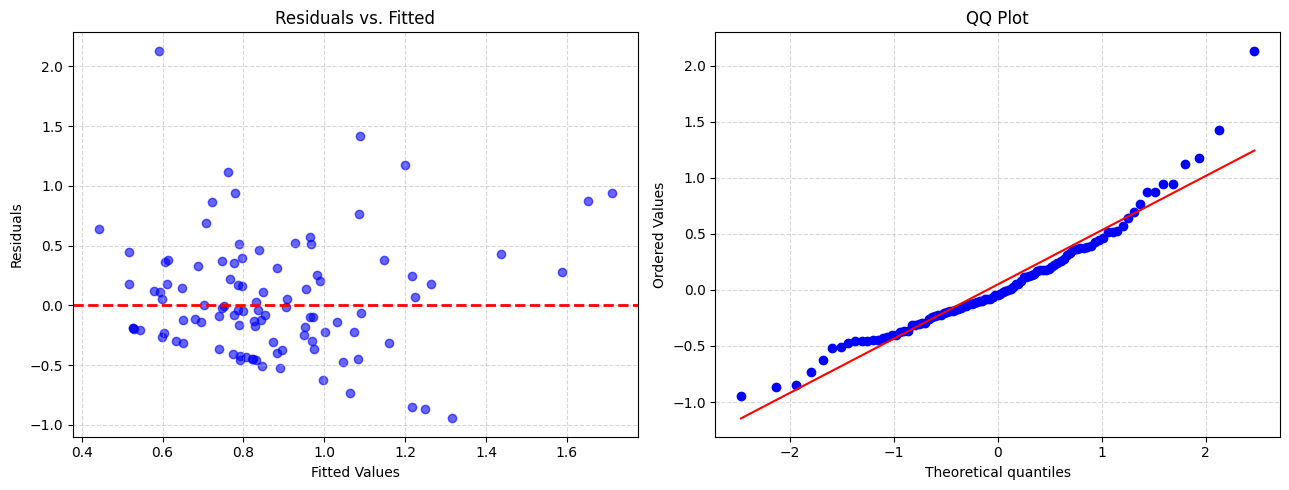

In [20]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# residuals vs. fitted - looking for random scatter around 0, no funnel shape, no curve
axes[0].scatter(y_pred, residuals, alpha=0.6, color='b')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')
axes[0].grid(True, linestyle='--', alpha=0.5)

# normal q-q plot - looking for points to follow the diagonal line
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [21]:
y_train_pred = pokemon_lm.predict(X_train)
y_test_pred = pokemon_lm.predict(X_test)

# calculate scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R^2: {train_r2:.4f}")
print(f"Test R^2:  {test_r2:.4f}")

Train R^2: 0.2546
Test R^2:  0.1993


In [22]:
test_rows = df.loc[X_test.index].copy()

test_rows['actual_log10'] = y_test
test_rows['pred_log10'] = y_pred

# turn back to real values
test_rows['predicted_price_usd'] = (10 ** y_pred) - 1
test_rows['price_error_usd'] = test_rows['predicted_price_usd'] - test_rows['price_usd']
test_rows['abs_error_usd'] = test_rows['price_error_usd'].abs()

columns_to_show = [
    'title', 'pokemon_name', 'set_name', 'condition_std', 
    'price_usd', 'predicted_price_usd', 'abs_error_usd'
]

display(
    test_rows.sort_values(by='abs_error_usd', ascending=True)[columns_to_show]
    .tail(10)
    .round(2)
)
print(test_rows.shape)

,title,pokemon_name,set_name,condition_std,price_usd,predicted_price_usd,abs_error_usd
491,Pokemon Card | Blastoise 2/102 Holo Rare Vinta...,Blastoise,BASE SET,Near Mint,72.38,37.66,34.72
492,Pokemon Card | Venusaur 15/102 Holo Rare Vinta...,Venusaur,BASE SET,Near Mint,72.38,26.44,45.94
283,Pokemon Card Skyridge Piloswine 24/144 E Serie...,Unknown,Unknown,Near Mint,51.69,5.01,46.68
529,Pokemon Gardevoir Holo Rare Card 6/113 Delta S...,Gardevoir,Unknown,Near Mint,69.77,11.17,58.60
207,Mega Froslass ex - Alt Art - 275/217 - Ascende...,Froslass,Unknown,Near Mint,74.95,4.77,70.18
46,Mega Dragonite ex 246/193 SAR Japanese Pokemo...,Dragonite,Unknown,Near Mint,234.52,14.83,219.69
383,Pokemon Charizard 4/102 Base Set Holo Rare Car...,Charizard,BASE SET,Near Mint,332.88,43.84,289.04
120,Pokemon Pikachu ex 001/030 WCS23 World Champio...,Pikachu,Unknown,Near Mint,321.63,11.24,310.39
290,Pokemon Mega Charizard Y Ex 294/217 ASC Ascend...,Charizard,Unknown,Near Mint,448.90,50.46,398.44
368,Mega Greninja ex Gold 120/083 MUR Ninja Spinne...,Greninja,Unknown,Near Mint,526.65,2.89,523.76


(101, 32)


In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM)

# linear regression - 5 fold cv
lm_cv_rmse = -cross_val_score(
    LinearRegression(), X, y, cv=kf, scoring='neg_root_mean_squared_error'
)
lm_cv_r2 = cross_val_score(
    LinearRegression(), X, y, cv=kf, scoring='r2'
)

print('Linear Regression 5-fold CV')
print(f'RMSE: {lm_cv_rmse.mean():.4f} +/- {lm_cv_rmse.std():.4f}')
print(f'R2:   {lm_cv_r2.mean():.4f} +/- {lm_cv_r2.std():.4f}')
print()

Linear Regression 5-fold CV
RMSE: 0.4684 +/- 0.0480
R2:   0.1652 +/- 0.0909




---

## Model 2: Random Forest

Implement bagging where every split considers all predictors 

In [24]:
features = X.shape[1]
rf_features = max(1, features // 3)

rf_pokemon = RandomForestRegressor(
    n_estimators=500,
    max_features=rf_features,
    oob_score=True,
    random_state=RANDOM,
)
rf_pokemon.fit(X_train, y_train)

yhat_rf = rf_pokemon.predict(X_test)
rf_test_mse = mean_squared_error(y_test, yhat_rf)
print(f'Random Forest (max_features={rf_features}) test MSE: {rf_test_mse:.4f}')

Random Forest (max_features=5) test MSE: 0.1751


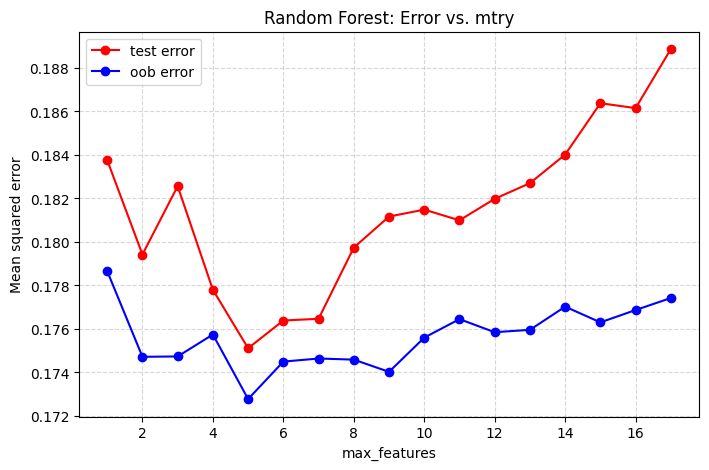

Best mtry by test error: 5 (test MSE = 0.1751)


In [25]:
test_error = []
oob_error = []

for m in range(1, features + 1):
    rf_m = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        oob_score=True,
        random_state=RANDOM,
        n_jobs=-1,
    )
    rf_m.fit(X_train, y_train)

    yhat_m = rf_m.predict(X_test)
    test_error.append(mean_squared_error(y_test, yhat_m))

    oob_mse = mean_squared_error(y_train, rf_m.oob_prediction_)
    oob_error.append(oob_mse)

mtry_range = range(1, features + 1)

plt.figure(figsize=(8, 5))
plt.plot(mtry_range, test_error, marker='o', color='red', label='test error')
plt.plot(mtry_range, oob_error, marker='o', color='blue', label='oob error')
plt.xlabel('max_features')
plt.ylabel('Mean squared error')
plt.title('Random Forest: Error vs. mtry')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

best_mtry = mtry_range[int(np.argmin(test_error))]
print(f'Best mtry by test error: {best_mtry} (test MSE = {min(test_error):.4f})')

In [26]:
rf_best = RandomForestRegressor(
    n_estimators=500,
    max_features=best_mtry,
    oob_score=True,
    random_state=RANDOM,
)
rf_best.fit(X_train, y_train)

yhat_best = rf_best.predict(X_test)
print(f'test MSE: {mean_squared_error(y_test, yhat_best):.4f}')
print(f'test R^2:  {r2_score(y_test, yhat_best):.4f}')



importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.to_string(index=False))

test MSE: 0.1751
test R^2:  0.4238
           Feature  Importance
   pokemon_encoded    0.211950
set_position_ratio    0.171740
      title_length    0.137080
  language_encoded    0.121868
       set_encoded    0.110605
      rarity_class    0.099254
     condition_std    0.048817
           is_holo    0.031693
        is_ex_card    0.019540
       is_full_art    0.016198
          is_promo    0.015181
    is_1st_edition    0.007553
         is_v_card    0.005764
        is_gx_card    0.002758
        is_rainbow    0.000000
           is_gold    0.000000
     is_shadowless    0.000000


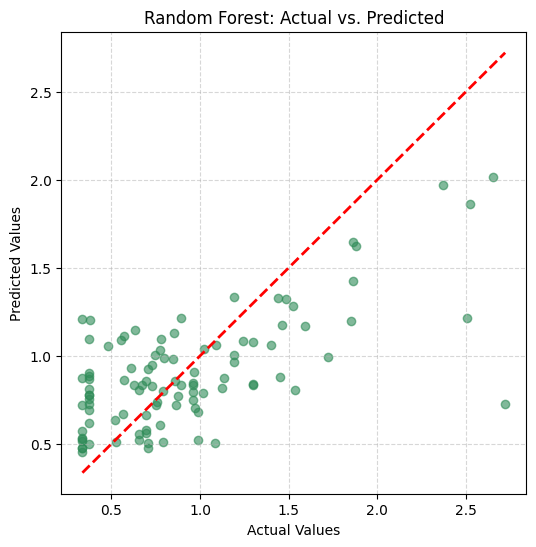

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_best, alpha=0.6, color='seagreen')

lims = [min(y_test.min(), yhat_best.min()), max(y_test.max(), yhat_best.max())]
plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: Actual vs. Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

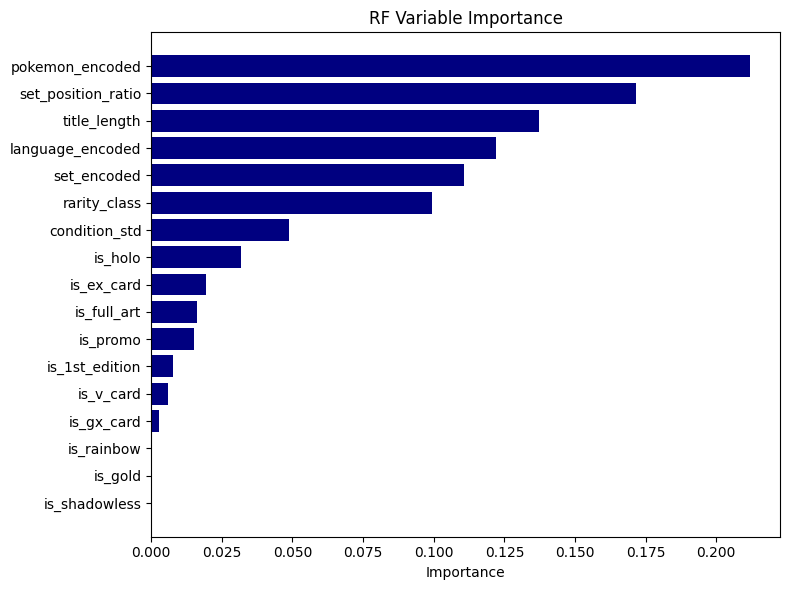

In [28]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='navy')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('RF Variable Importance')
plt.tight_layout()
plt.show()

In [29]:
rf_cv_model = RandomForestRegressor(
    n_estimators=300,
    max_features=best_mtry,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM,
)

rf_cv_rmse = -cross_val_score(
    rf_cv_model, X, y, cv=kf, scoring='neg_root_mean_squared_error'
)
rf_cv_r2 = cross_val_score(
    rf_cv_model, X, y, cv=kf, scoring='r2'
)

print('Random Forest 5-fold CV')
print(f'RMSE: {rf_cv_rmse.mean():.4f} +/- {rf_cv_rmse.std():.4f}')
print(f'R2:   {rf_cv_r2.mean():.4f} +/- {rf_cv_r2.std():.4f}')

Random Forest 5-fold CV
RMSE: 0.4313 +/- 0.0273
R2:   0.2869 +/- 0.0865


Additional code for report visuals:

Random forest report visuals:

In [47]:
rf_test_rows = df.loc[X_test.index].copy()

rf_test_rows['actual_log10'] = y_test
rf_test_rows['pred_log10'] = yhat_best

# turn back to real values
rf_test_rows['predicted_price_usd'] = (10 ** yhat_best) - 1
rf_test_rows['price_error_usd'] = rf_test_rows['predicted_price_usd'] - rf_test_rows['price_usd']
rf_test_rows['abs_error_usd'] = rf_test_rows['price_error_usd'].abs()

rf_columns_to_show = [
    'title', 'pokemon_name', 'set_name', 'condition_std', 
    'price_usd', 'predicted_price_usd', 'abs_error_usd'
]

print("Random Forest")
display(
    rf_test_rows.sort_values(by='abs_error_usd', ascending=True)[rf_columns_to_show]
    .tail(10)
    .round(2)
)
print(rf_test_rows.shape)

Random Forest


,title,pokemon_name,set_name,condition_std,price_usd,predicted_price_usd,abs_error_usd
491,Pokemon Card | Blastoise 2/102 Holo Rare Vinta...,Blastoise,BASE SET,Near Mint,72.38,43.31,29.07
207,Mega Froslass ex - Alt Art - 275/217 - Ascende...,Froslass,Unknown,Near Mint,74.95,40.94,34.01
283,Pokemon Card Skyridge Piloswine 24/144 E Serie...,Unknown,Unknown,Near Mint,51.69,8.87,42.82
492,Pokemon Card | Venusaur 15/102 Holo Rare Vinta...,Venusaur,BASE SET,Near Mint,72.38,25.57,46.81
529,Pokemon Gardevoir Holo Rare Card 6/113 Delta S...,Gardevoir,Unknown,Near Mint,69.77,14.80,54.97
46,Mega Dragonite ex 246/193 SAR Japanese Pokemo...,Dragonite,Unknown,Near Mint,234.52,92.93,141.59
383,Pokemon Charizard 4/102 Base Set Holo Rare Car...,Charizard,BASE SET,Near Mint,332.88,71.70,261.18
120,Pokemon Pikachu ex 001/030 WCS23 World Champio...,Pikachu,Unknown,Near Mint,321.63,15.52,306.11
290,Pokemon Mega Charizard Y Ex 294/217 ASC Ascend...,Charizard,Unknown,Near Mint,448.90,103.11,345.79
368,Mega Greninja ex Gold 120/083 MUR Ninja Spinne...,Greninja,Unknown,Near Mint,526.65,4.31,522.34


(101, 32)
